In [ ]:
# rename from combined_signal.ipynb to comparison_original_catalog_and_combined_catalog_together.ipynb

In [2]:
import treecorr
import numpy as np
import matplotlib.pyplot as plt
import os
from astropy.table import Table
import pandas as pd
import polars as pl

try:
    plt.style.use('/home/dy9683/cosmic-shear/cosmic-shear-with-spec-z/paperfigs.mplstyle')
except Exception as e:
    print(f'Error: {e}')
    
from utils import get_catalog_columns
from utils import get_shear_correlation

# 0. Load Files

In [3]:
datadir_root = '/scratch/gpfs/dy9683/'
datadir = os.path.join(datadir_root, 'matched_catalogs')

datadir_hscy3 = os.path.join(datadir, "hscy3_matched_lensing_match_1.csv")
datadir_desy3 = os.path.join(datadir, "desy3_matched_lensing_match_1.csv")
datadir_decade = os.path.join(datadir, "decade_matched_lensing_match_1.csv")
datadir_kidslegacy = os.path.join(datadir, "kidslegacy_matched_lensing_match_1.csv")
datadir_combined = os.path.join(datadir, "hsc_des_decade_combined_lensing_match_1.csv")
datadir_combined_with_duplicates = os.path.join(datadir, "hsc_des_decade_combined_with_duplicates_lensing_match_1.csv")

In [4]:
hsc_catalog = pd.read_csv(datadir_hscy3)
des_catalog = pd.read_csv(datadir_desy3)
decade_catalog = pd.read_csv(datadir_decade)
kidslegacy_catalog = pd.read_csv(datadir_kidslegacy)

In [5]:
combined_catalog = pd.read_csv(datadir_combined)
combined_with_duplicates_catalog = pd.read_csv(datadir_combined_with_duplicates)

In [15]:
datadir_desi_redshift = os.path.join(datadir_root, "desi_redshifts.csv")
desi_redshift_catalog = pd.read_csv(datadir_desi_redshift)

## Load necessary variables

In [6]:
ra_hsc, dec_hsc, g1_hsc, g2_hsc, z_hsc = get_catalog_columns(hsc_catalog)
ra_des, dec_des, g1_des, g2_des, z_des = get_catalog_columns(des_catalog)
ra_decade, dec_decade, g1_decade, g2_decade, z_decade = get_catalog_columns(decade_catalog)
ra_kidslegacy, dec_kidslegacy, g1_kidslegacy, g2_kidslegacy, z_kidslegacy = get_catalog_columns(kidslegacy_catalog)

In [7]:
ra_combined, dec_combined, g1_combined, g2_combined, z_combined = get_catalog_columns(combined_catalog)

In [8]:
ra_combined_with_duplicates, dec_combined_with_duplicates, g1_combined_with_duplicates, g2_combined_with_duplicates, z_combined_with_duplicates = get_catalog_columns(combined_with_duplicates_catalog)

In [21]:
desi_redshift = desi_redshift_catalog['Z_BEST']

# 1. TreeCorr Code

In [9]:
datasets = {
    'hsc': {'ra': ra_hsc, 'dec': dec_hsc, 'g1': g1_hsc, 'g2': g2_hsc},
    'des': {'ra': ra_des, 'dec': dec_des, 'g1': g1_des, 'g2': g2_des},
    'decade': {'ra': ra_decade, 'dec': dec_decade, 'g1': g1_decade, 'g2': g2_decade},
    'kidslegacy': {'ra': ra_kidslegacy, 'dec': dec_kidslegacy, 'g1': g1_kidslegacy, 'g2': g2_kidslegacy},
    'combined': {'ra': ra_combined, 'dec': dec_combined, 'g1': g1_combined, 'g2': g2_combined},
    'combined_with_duplicates': {'ra': ra_combined_with_duplicates, 'dec': dec_combined_with_duplicates, 
                                 'g1': g1_combined_with_duplicates, 'g2': g2_combined_with_duplicates}
}

In [10]:
results = {}
for name, data in datasets.items():
    results[name] = get_shear_correlation(
        ra=data['ra'], 
        dec=data['dec'], 
        g1=data['g1'], 
        g2=data['g2'])

In [11]:
for cat_name, data in results.items():
    globals()[f"xip_{cat_name}"] = data['xip']
    globals()[f"xim_{cat_name}"] = data['xim']
    globals()[f"r_{cat_name}"] = data['r']
    globals()[f"sig_xip_{cat_name}"] = data['sig_xip']
    globals()[f"sig_xim_{cat_name}"] = data['sig_xim']

# 2. Comparison Plots

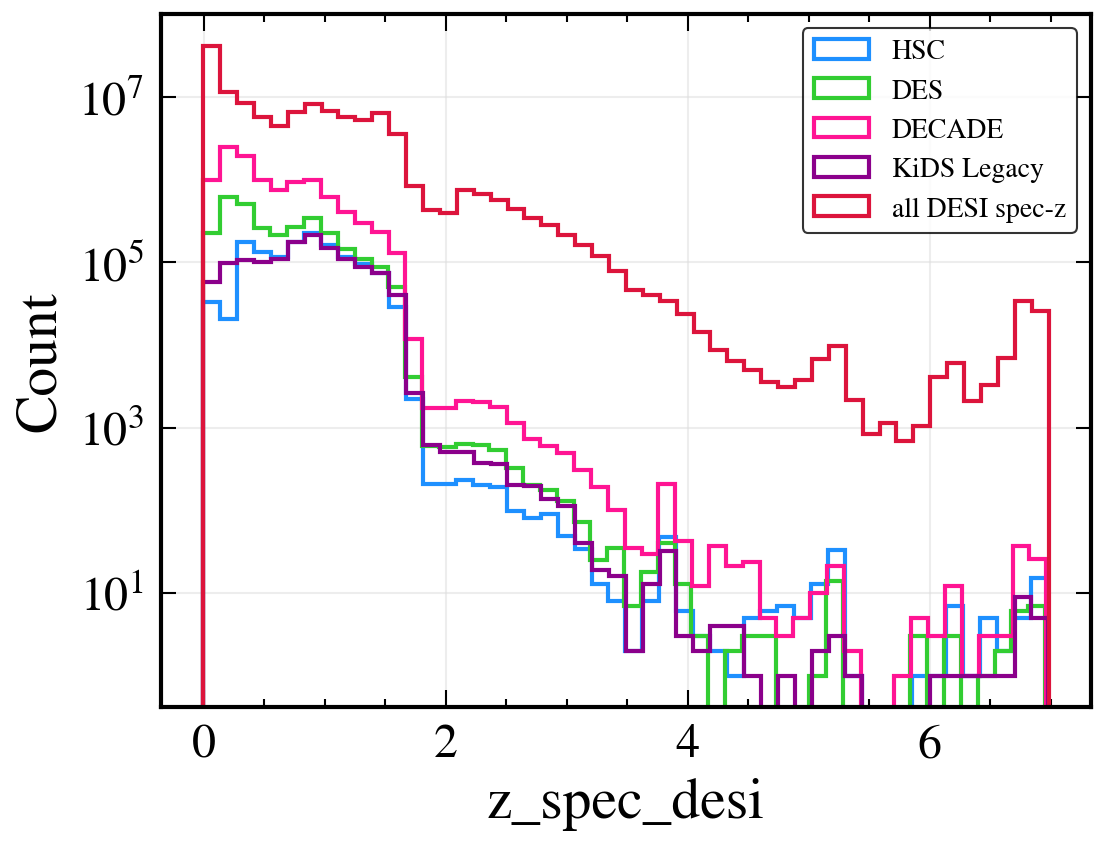

In [22]:
fig, ax = plt.subplots(figsize = (8,6))

ax.hist(z_hsc, bins = 50 , density = False, color = "dodgerblue", histtype = "step", label = "HSC", lw = 2)
ax.hist(z_des, bins = 50 , density = False, color = "limegreen", histtype = "step", label = "DES", lw = 2)
ax.hist(z_decade, bins = 50 , density = False, color = "deeppink", histtype = "step", label = "DECADE", lw = 2 )
ax.hist(z_kidslegacy, bins = 50 , density = False, color = "darkmagenta", histtype = "step", label = "KiDS Legacy", lw = 2)
# ax.hist(z_combined, bins = 50 , density = False, color = "black", histtype = "step", label = "Combined", lw = 2)
ax.hist(desi_redshift, bins = 50 , density = False, color = "crimson", histtype = "step", label = "all DESI spec-z", lw = 2)

ax.legend()
ax.set_xlabel("z_spec_desi")
ax.set_ylabel("Count")
ax.set_yscale('log')
plt.show()

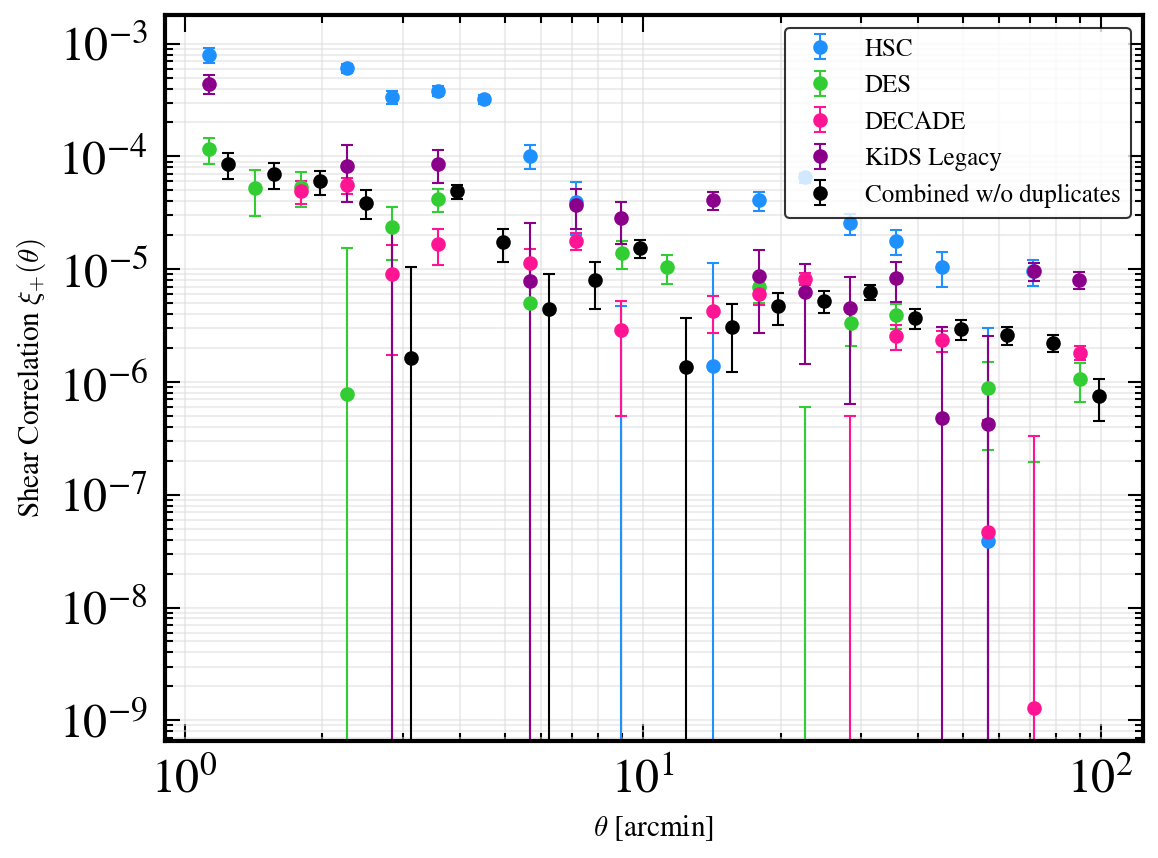

In [23]:
# xi_+
fig, ax = plt.subplots(figsize=(8, 6))

ax.errorbar(r_hsc, xip_hsc, yerr=sig_xip_hsc, label="HSC", color='dodgerblue', capsize=3, fmt = "o")
ax.errorbar(r_des, xip_des, yerr=sig_xip_des, label="DES", color='limegreen', capsize=3, fmt = "o")
ax.errorbar(r_decade, xip_decade, yerr=sig_xip_decade, label="DECADE", color='deeppink', capsize=3, fmt = "o")
ax.errorbar(r_kidslegacy, xip_kidslegacy, yerr=sig_xip_kidslegacy, label="KiDS Legacy", color='darkmagenta', capsize=3, fmt = "o")
ax.errorbar(r_combined * 1.1, xip_combined, yerr=sig_xip_combined, label="Combined w/o duplicates", color='black', capsize=3, fmt = "o")

ax.set_xscale('log')
ax.set_yscale('log') 
ax.set_xlabel(r'$\theta$ [arcmin]', fontsize=14)
ax.set_ylabel(r'Shear Correlation $\xi_{+}(\theta)$', fontsize=14)
ax.legend(fontsize=12)
ax.grid(True, which='both', color='gainsboro', alpha=0.5)

plt.tight_layout()
plt.show()

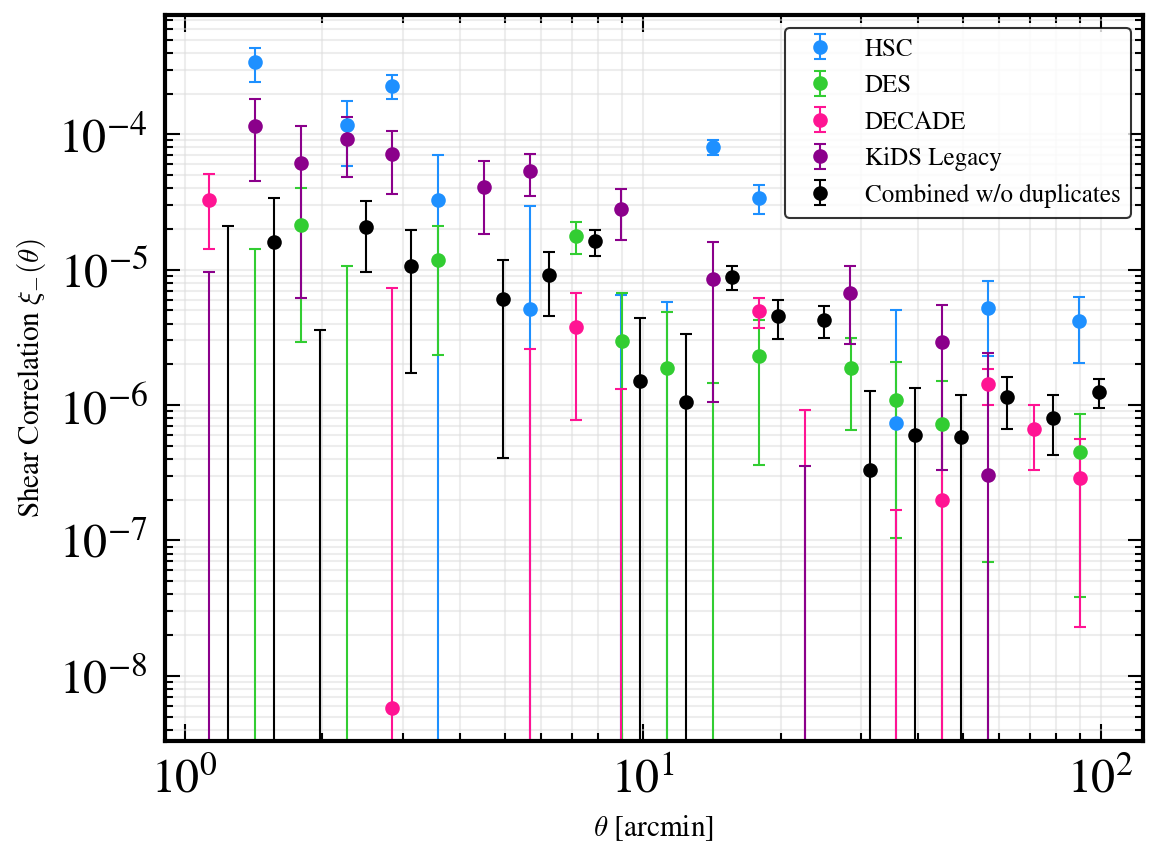

In [24]:
# xi_-
fig, ax = plt.subplots(figsize=(8, 6))

ax.errorbar(r_hsc, xim_hsc, yerr=sig_xim_hsc, label="HSC", color='dodgerblue', capsize=3, fmt = "o")
ax.errorbar(r_des, xim_des, yerr=sig_xim_des, label="DES", color='limegreen', capsize=3, fmt = "o")
ax.errorbar(r_decade, xim_decade, yerr=sig_xim_decade, label="DECADE", color='deeppink', capsize=3, fmt = "o")
ax.errorbar(r_kidslegacy, xim_kidslegacy, yerr=sig_xim_kidslegacy, label="KiDS Legacy", color='darkmagenta', capsize=3, fmt = "o")
ax.errorbar(r_combined * 1.1, xim_combined, yerr=sig_xim_combined, label="Combined w/o duplicates", color='black', capsize=3, fmt = "o")

ax.set_xscale('log')
ax.set_yscale('log') 
ax.set_xlabel(r'$\theta$ [arcmin]', fontsize=14)
ax.set_ylabel(r'Shear Correlation $\xi_{-}(\theta)$', fontsize=14)
ax.legend(fontsize=12)
ax.grid(True, which='both', color='gainsboro', alpha=0.5)

plt.tight_layout()
plt.show()

# 3. Combined catalog sanity checks (06/25)

## Without duplicates

In [25]:
# you have individual catalogs and combined catalogs 
# need: from combined catalog, signal of individual catalogs (fmt cross color)
# take combined_catalog, make three subcatalogs based on "catalog" selection, rerun ra,dec code - treecorr code

In [26]:
combined_catalog_hsc = combined_catalog[combined_catalog['catalog'] == 'hsc']
combined_catalog_des = combined_catalog[combined_catalog['catalog'] == 'des']
combined_catalog_decade = combined_catalog[combined_catalog['catalog'] == 'decade']

In [27]:
print(f"Lenght of HSC galaxies from combined catalog: {len(combined_catalog_hsc):,}")
print(f"Lenght of DES galaxies from combined catalog: {len(combined_catalog_des):,}")
print(f"Lenght of DECADE galaxies from combined catalog: {len(combined_catalog_decade):,}")

Lenght of HSC galaxies from combined catalog: 967,581
Lenght of DES galaxies from combined catalog: 2,379,130
Lenght of DECADE galaxies from combined catalog: 8,912,354


In [28]:
ra_combined_hsc, dec_combined_hsc, g1_combined_hsc, g2_combined_hsc, z_combined_hsc = get_catalog_columns(combined_catalog_hsc)
ra_combined_des, dec_combined_des, g1_combined_des, g2_combined_des, z_combined_des = get_catalog_columns(combined_catalog_des)
ra_combined_decade, dec_combined_decade, g1_combined_decade, g2_combined_decade, z_combined_decade = get_catalog_columns(combined_catalog_decade)

### Treecorr

In [29]:
datasets_combined = {
    'combined_hsc': {'ra': ra_combined_hsc, 'dec': dec_combined_hsc, 'g1': g1_combined_hsc, 'g2': g2_combined_hsc},
    'combined_des': {'ra': ra_combined_des, 'dec': dec_combined_des, 'g1': g1_combined_des, 'g2': g2_combined_des},
    'combined_decade': {'ra': ra_combined_decade, 'dec': dec_combined_decade, 'g1': g1_combined_decade, 'g2': g2_combined_decade},
}

In [ ]:
results_combined = {}
for name, data in datasets_combined.items():
    results_combined[name] = get_shear_correlation(
        ra=data['ra'], 
        dec=data['dec'], 
        g1=data['g1'], 
        g2=data['g2'])

In [32]:
for cat_name, data in results_combined.items():
    globals()[f"xip_{cat_name}"] = data['xip']
    globals()[f"xim_{cat_name}"] = data['xim']
    globals()[f"r_{cat_name}"] = data['r']
    globals()[f"sig_xip_{cat_name}"] = data['sig_xip']
    globals()[f"sig_xim_{cat_name}"] = data['sig_xim']

### Plots

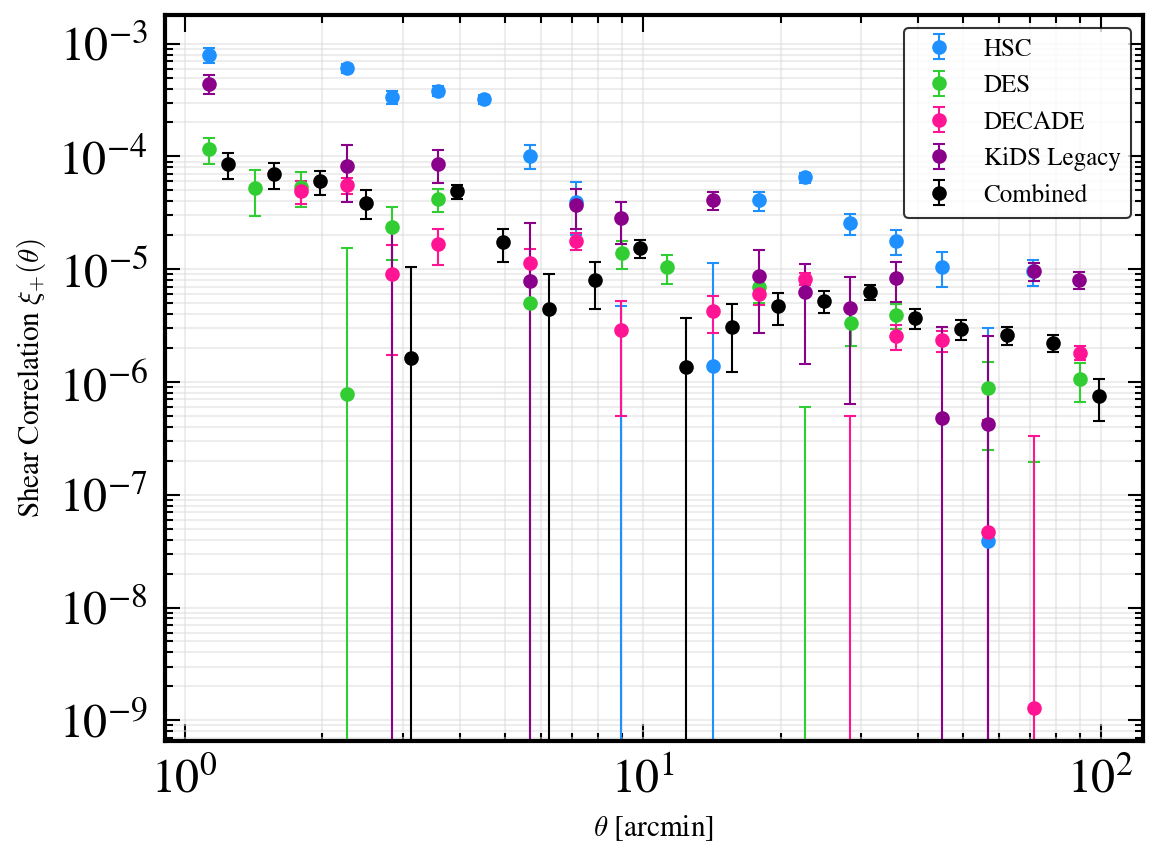

In [45]:
# xi_+
fig, ax = plt.subplots(figsize=(8, 6))

ax.errorbar(r_hsc, xip_hsc, yerr=sig_xip_hsc, label="HSC", color='dodgerblue', capsize=3, fmt = "o")
ax.errorbar(r_des, xip_des, yerr=sig_xip_des, label="DES", color='limegreen', capsize=3, fmt = "o")
ax.errorbar(r_decade, xip_decade, yerr=sig_xip_decade, label="DECADE", color='deeppink', capsize=3, fmt = "o")
ax.errorbar(r_kidslegacy, xip_kidslegacy, yerr=sig_xip_kidslegacy, label="KiDS Legacy", color='darkmagenta', capsize=3, fmt = "o")
ax.errorbar(r_combined * 1.1, xip_combined, yerr=sig_xip_combined, label="Combined", color='black', capsize=3, fmt = "o")

ax.set_xscale('log')
ax.set_yscale('log') 
ax.set_xlabel(r'$\theta$ [arcmin]', fontsize=14)
ax.set_ylabel(r'Shear Correlation $\xi_{+}(\theta)$', fontsize=14)
ax.legend(fontsize=12)
ax.grid(True, which='both', color='gainsboro', alpha=0.5)

plt.tight_layout()
plt.show()

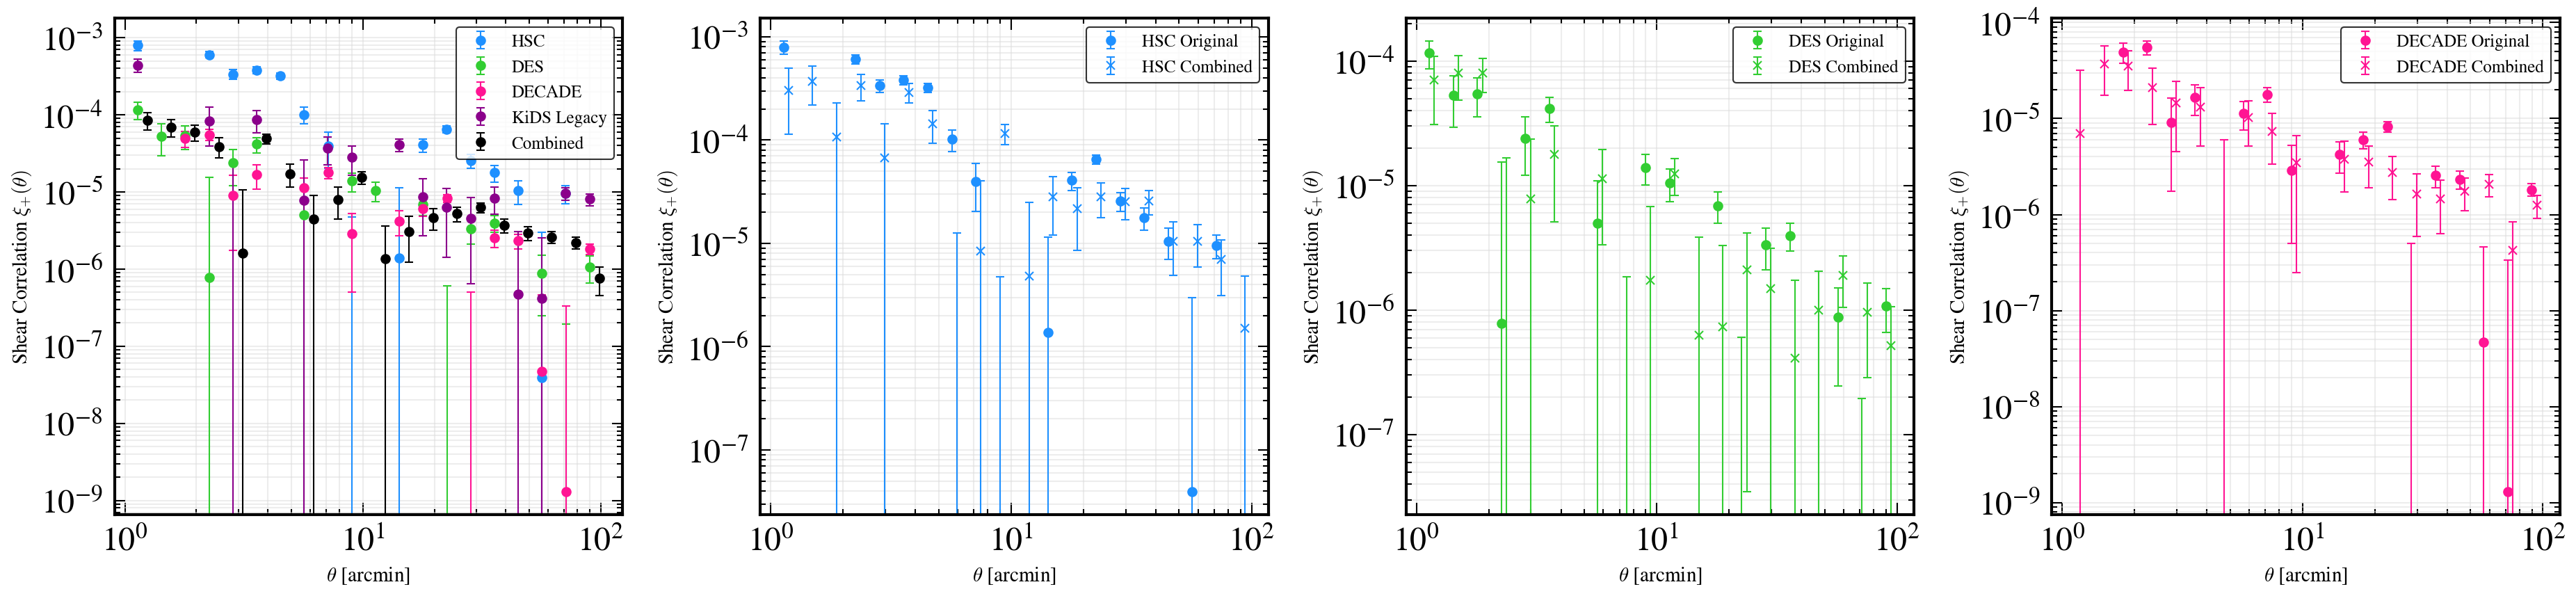

In [39]:
fig, ax = plt.subplots(1,4, figsize = (25,6))

ax[0].errorbar(r_hsc, xip_hsc, yerr=sig_xip_hsc, label="HSC", color='dodgerblue', capsize=3, fmt = "o")
ax[0].errorbar(r_des, xip_des, yerr=sig_xip_des, label="DES", color='limegreen', capsize=3, fmt = "o")
ax[0].errorbar(r_decade, xip_decade, yerr=sig_xip_decade, label="DECADE", color='deeppink', capsize=3, fmt = "o")
ax[0].errorbar(r_kidslegacy, xip_kidslegacy, yerr=sig_xip_kidslegacy, label="KiDS Legacy", color='darkmagenta', capsize=3, fmt = "o")
ax[0].errorbar(r_combined * 1.1, xip_combined, yerr=sig_xip_combined, label="Combined", color='black', capsize=3, fmt = "o")

ax[1].errorbar(r_hsc, xip_hsc, yerr=sig_xip_hsc, label="HSC Original", color='dodgerblue', capsize=3, fmt = "o")
ax[1].errorbar(1.05 * r_combined_hsc, xip_combined_hsc, yerr=sig_xip_combined_hsc, label="HSC Combined", color='dodgerblue', capsize=3, fmt = "x")

ax[2].errorbar(r_des, xip_des, yerr=sig_xip_des, label="DES Original", color='limegreen', capsize=3, fmt = "o")
ax[2].errorbar(1.05 * r_combined_des, xip_combined_des, yerr=sig_xip_combined_des, label="DES Combined", color='limegreen', capsize=3, fmt = "x")

ax[3].errorbar(r_decade, xip_decade, yerr=sig_xip_decade, label="DECADE Original", color='deeppink', capsize=3, fmt = "o")
ax[3].errorbar(1.05 * r_combined_deacde, xip_combined_deacde, yerr=sig_xip_combined_deacde, label="DECADE Combined", color='deeppink', capsize=3, fmt = "x")

for i in range(4):
    ax[i].set_xscale('log')
    ax[i].set_yscale('log') 
    ax[i].set_xlabel(r'$\theta$ [arcmin]', fontsize=14)
    ax[i].set_ylabel(r'Shear Correlation $\xi_{+}(\theta)$', fontsize=14)
    ax[i].legend(fontsize=12)
    ax[i].grid(True, which='both', color='gainsboro', alpha=0.5)

plt.tight_layout()
plt.show()

## With Duplicates

In [40]:
combined_with_duplicates_catalog_hsc = combined_with_duplicates_catalog[combined_with_duplicates_catalog['catalog'] == 'hsc']
combined_with_duplicates_catalog_des = combined_with_duplicates_catalog[combined_with_duplicates_catalog['catalog'] == 'des']
combined_with_duplicates_catalog_decade = combined_with_duplicates_catalog[combined_with_duplicates_catalog['catalog'] == 'decade']

In [41]:
print(f"Length of HSC galaxies from combined catalog (with duplicates): {len(combined_with_duplicates_catalog_hsc):,}")
print(f"Length of DES galaxies from combined catalog (with duplicates): {len(combined_with_duplicates_catalog_des):,}")
print(f"Length of DECADE galaxies from combined catalog (with duplicates): {len(combined_with_duplicates_catalog_decade):,}")

Length of HSC galaxies from combined catalog (with duplicates): 1,358,425
Length of DES galaxies from combined catalog (with duplicates): 2,870,224
Length of DECADE galaxies from combined catalog (with duplicates): 10,309,765


In [42]:
ra_combined_with_duplicates_hsc, dec_combined_with_duplicates_hsc, g1_combined_with_duplicates_hsc, g2_combined_with_duplicates_hsc, z_combined_with_duplicates_hsc = get_catalog_columns(combined_with_duplicates_catalog_hsc)
ra_combined_with_duplicates_des, dec_combined_with_duplicates_des, g1_combined_with_duplicates_des, g2_combined_with_duplicates_des, z_combined_with_duplicates_des = get_catalog_columns(combined_with_duplicates_catalog_des)
ra_combined_with_duplicates_decade, dec_combined_with_duplicates_decade, g1_combined_with_duplicates_decade, g2_combined_with_duplicates_decade, z_combined_with_duplicates_decade = get_catalog_columns(combined_with_duplicates_catalog_decade)

### Treecorr

In [43]:
datasets_combined_with_duplicates = {
    'combined_with_duplicates_hsc': {'ra': ra_combined_with_duplicates_hsc, 'dec': dec_combined_with_duplicates_hsc, 'g1': g1_combined_with_duplicates_hsc, 'g2': g2_combined_with_duplicates_hsc},
    'combined_with_duplicates_des': {'ra': ra_combined_with_duplicates_des, 'dec': dec_combined_with_duplicates_des, 'g1': g1_combined_with_duplicates_des, 'g2': g2_combined_with_duplicates_des},
    'combined_with_duplicates_decade': {'ra': ra_combined_with_duplicates_decade, 'dec': dec_combined_with_duplicates_decade, 'g1': g1_combined_with_duplicates_decade, 'g2': g2_combined_with_duplicates_decade},
}

In [44]:
results_combined_with_duplicates = {}
for name, data in datasets_combined_with_duplicates.items():
    results_combined_with_duplicates[name] = get_shear_correlation(
        ra=data['ra'], 
        dec=data['dec'], 
        g1=data['g1'], 
        g2=data['g2'])

In [46]:
for cat_name, data in results_combined_with_duplicates.items():
    globals()[f"xip_{cat_name}"] = data['xip']
    globals()[f"xim_{cat_name}"] = data['xim']
    globals()[f"r_{cat_name}"] = data['r']
    globals()[f"sig_xip_{cat_name}"] = data['sig_xip']
    globals()[f"sig_xim_{cat_name}"] = data['sig_xim']

### Plots

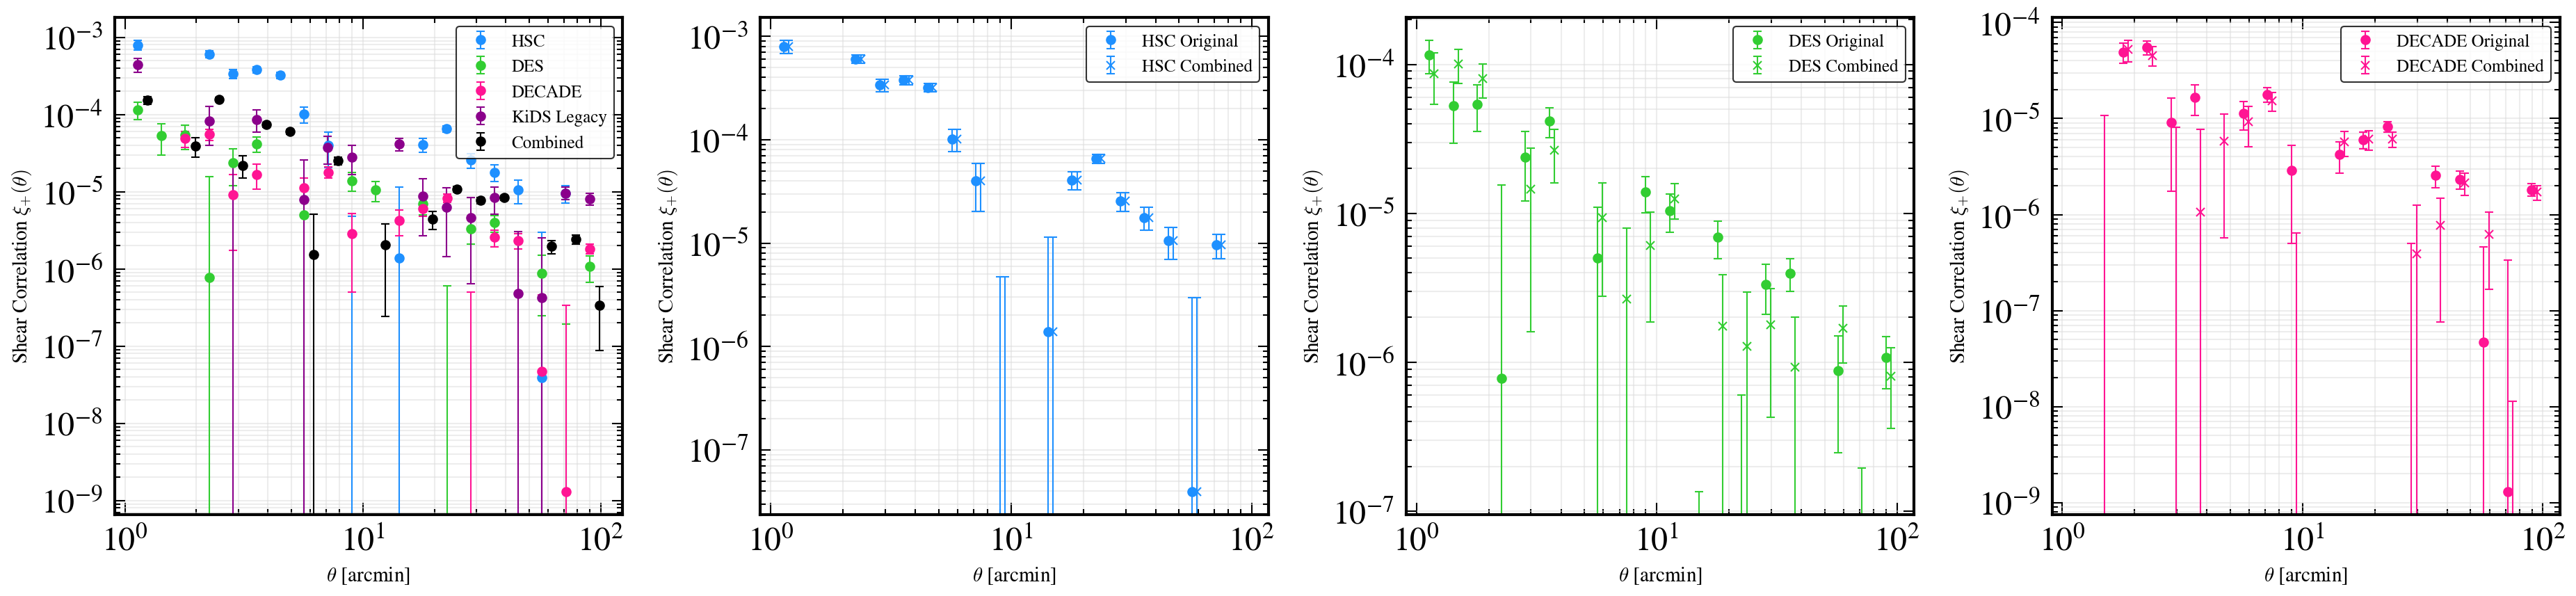

In [47]:
fig, ax = plt.subplots(1,4, figsize = (25,6))

ax[0].errorbar(r_hsc, xip_hsc, yerr=sig_xip_hsc, label="HSC", color='dodgerblue', capsize=3, fmt = "o")
ax[0].errorbar(r_des, xip_des, yerr=sig_xip_des, label="DES", color='limegreen', capsize=3, fmt = "o")
ax[0].errorbar(r_decade, xip_decade, yerr=sig_xip_decade, label="DECADE", color='deeppink', capsize=3, fmt = "o")
ax[0].errorbar(r_kidslegacy, xip_kidslegacy, yerr=sig_xip_kidslegacy, label="KiDS Legacy", color='darkmagenta', capsize=3, fmt = "o")
ax[0].errorbar(r_combined_with_duplicates * 1.1, xip_combined_with_duplicates, yerr=sig_xip_combined_with_duplicates, label="Combined", color='black', capsize=3, fmt = "o")

ax[1].errorbar(r_hsc, xip_hsc, yerr=sig_xip_hsc, label="HSC Original", color='dodgerblue', capsize=3, fmt = "o")
ax[1].errorbar(1.05 * r_combined_with_duplicates_hsc, xip_combined_with_duplicates_hsc, yerr=sig_xip_combined_with_duplicates_hsc, label="HSC Combined", color='dodgerblue', capsize=3, fmt = "x")

ax[2].errorbar(r_des, xip_des, yerr=sig_xip_des, label="DES Original", color='limegreen', capsize=3, fmt = "o")
ax[2].errorbar(1.05 * r_combined_with_duplicates_des, xip_combined_with_duplicates_des, yerr=sig_xip_combined_with_duplicates_des, label="DES Combined", color='limegreen', capsize=3, fmt = "x")

ax[3].errorbar(r_decade, xip_decade, yerr=sig_xip_decade, label="DECADE Original", color='deeppink', capsize=3, fmt = "o")
ax[3].errorbar(1.05 * r_combined_with_duplicates_decade, xip_combined_with_duplicates_decade, yerr=sig_xip_combined_with_duplicates_decade, label="DECADE Combined", color='deeppink', capsize=3, fmt = "x")

for i in range(4):
    ax[i].set_xscale('log')
    ax[i].set_yscale('log') 
    ax[i].set_xlabel(r'$\theta$ [arcmin]', fontsize=14)
    ax[i].set_ylabel(r'Shear Correlation $\xi_{+}(\theta)$', fontsize=14)
    ax[i].legend(fontsize=12)
    ax[i].grid(True, which='both', color='gainsboro', alpha=0.5)

plt.tight_layout()
plt.show()